# Coding Assignment 1: Comparative Analysis of Machine Learning Models for Medical Diagnostics

# ID 2671508 _ Tasnuba Tasnim

## Phase A: Data Engineering

In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Load the Breast Cancer Wisconsin dataset
breast_cancer_data = load_breast_cancer()

# Transform
data_frame = pd.DataFrame(data=breast_cancer_data.data, columns=breast_cancer_data.feature_names)
data_frame['target_variable'] = breast_cancer_data.target

display(data_frame.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target_variable
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
# any missing values within the dataset
null_counts = data_frame.isnull().sum()

if null_counts.sum() == 0:
    print("The dataset is complete; no missing values were detected.")
else:
    print("Columns with identified missing values:")
    display(null_counts[null_counts > 0])

The dataset is complete; no missing values were detected.


### Feature Normalization: Applying StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler

# Isolate the predictive features (X) from the target variable (y)
features = data_frame.drop('target_variable', axis=1)
target_labels = data_frame['target_variable']

# StandardScaler for scaling
standard_scaler = StandardScaler()

# Execute the scaling transformation on the features
scaled_features_array = standard_scaler.fit_transform(features)

# Reconstruct a DataFrame from the scaled features for better readability and structure
scaled_features_df = pd.DataFrame(scaled_features_array, columns=features.columns)

print("Features have been successfully scaled. Presenting the initial 5 rows of the scaled feature set:")
display(scaled_features_df.head())

Features have been successfully scaled. Presenting the initial 5 rows of the scaled feature set:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


### Feature Correlation Matrix: Identifying the top five features.

In [ ]:
# Integrate the scaled features with the target variable for correlation analysis
combined_data_scaled = pd.DataFrame(scaled_features_array, columns=features.columns)
combined_data_scaled['target_variable'] = target_labels

# Compute the correlation matrix
correlation_metrics = combined_data_scaled.corr()

# Extract the absolute correlation values with the target variable and rank them in descending order
target_correlation_abs = correlation_metrics['target_variable'].abs().sort_values(ascending=False)

# Showcase the top 5 features correlated with the target, excluding the target itself
highly_correlated_features = target_correlation_abs.drop('target_variable').head(5)

print("The top 5 features demonstrating the highest absolute correlation with the target variable are:")
display(highly_correlated_features)

The top 5 features demonstrating the highest absolute correlation with the target variable are:


,target_variable
worst concave points,0.793566
worst perimeter,0.782914
mean concave points,0.776614
worst radius,0.776454
mean perimeter,0.742636


## Phase B: Model Implementation (Using Scikit-Learn)

#### Dataset Partitioning

In [ ]:
from sklearn.model_selection import train_test_split

# Divide the preprocessed data into training and testing subsets
train_features, test_features, train_labels, test_labels = train_test_split(
    scaled_features_array, target_labels, test_size=0.3, random_state=42
)

print(f"Shape of training features: {train_features.shape}")
print(f"Shape of testing features: {test_features.shape}")
print(f"Shape of training labels: {train_labels.shape}")
print(f"Shape of testing labels: {test_labels.shape}")

Shape of training features: (398, 30)
Shape of testing features: (171, 30)
Shape of training labels: (398,)
Shape of testing labels: (171,)


#### 1. Logistic Regression (Our Initial Benchmark Model)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Initialize and train the Logistic Regression classifier
logistic_reg_classifier = LogisticRegression(random_state=42, solver='liblinear')
logistic_reg_classifier.fit(train_features, train_labels)

# Generate predictions on test dataset
predictions_logistic_reg = logistic_reg_classifier.predict(test_features)

# optput of the Logistic Regression model
log_reg_accuracy = accuracy_score(test_labels, predictions_logistic_reg)
log_reg_precision = precision_score(test_labels, predictions_logistic_reg)
log_reg_recall = recall_score(test_labels, predictions_logistic_reg)

print(f"Logistic Regression Classifier Accuracy: {log_reg_accuracy:.4f}")
print(f"Logistic Regression Classifier Precision: {log_reg_precision:.4f}")
print(f"Logistic Regression Classifier Recall: {log_reg_recall:.4f}")

Logistic Regression Classifier Accuracy: 0.9825
Logistic Regression Classifier Precision: 0.9907
Logistic Regression Classifier Recall: 0.9815


#### 2. Random Forest Classifier (An Ensemble Learning Approach)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(train_features, train_labels)

# Obtain predictions using the test data
predictions_rf = rf_classifier.predict(test_features)

# Evaluate the Random Forest model performance
rf_accuracy = accuracy_score(test_labels, predictions_rf)
rf_precision = precision_score(test_labels, predictions_rf)
rf_recall = recall_score(test_labels, predictions_rf)

print(f"Random Forest Classifier Accuracy: {rf_accuracy:.4f}")
print(f"Random Forest Classifier Precision: {rf_precision:.4f}")
print(f"Random Forest Classifier Recall: {rf_recall:.4f}")

Random Forest Classifier Accuracy: 0.9708
Random Forest Classifier Precision: 0.9640
Random Forest Classifier Recall: 0.9907


#### 3. Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import SVC

# Initialize and train the Support Vector Machine model
svm_classifier = SVC(random_state=42)
svm_classifier.fit(train_features, train_labels)

# Make predictions against the test set
predictions_svm = svm_classifier.predict(test_features)

# Compute evaluation metrics for the SVM model
svm_accuracy = accuracy_score(test_labels, predictions_svm)
svm_precision = precision_score(test_labels, predictions_svm)
svm_recall = recall_score(test_labels, predictions_svm)

print(f"SVM Classifier Accuracy: {svm_accuracy:.4f}")
print(f"SVM Classifier Precision: {svm_precision:.4f}")
print(f"SVM Classifier Recall: {svm_recall:.4f}")

# dictionary library so that I can use later
performance_metrics_all_models = {
    'Logistic Regression': {
        'Accuracy': log_reg_accuracy,
        'Precision': log_reg_precision,
        'Recall': log_reg_recall
    },
    'Random Forest': {
        'Accuracy': rf_accuracy,
        'Precision': rf_precision,
        'Recall': rf_recall
    },
    'SVM': {
        'Accuracy': svm_accuracy,
        'Precision': svm_precision,
        'Recall': svm_recall
    }
}

SVM Classifier Accuracy: 0.9708
SVM Classifier Precision: 0.9813
SVM Classifier Recall: 0.9722


## Phase C: Data Visualization (Utilizing Matplotlib and Seaborn)

#### Model Performance Comparison:

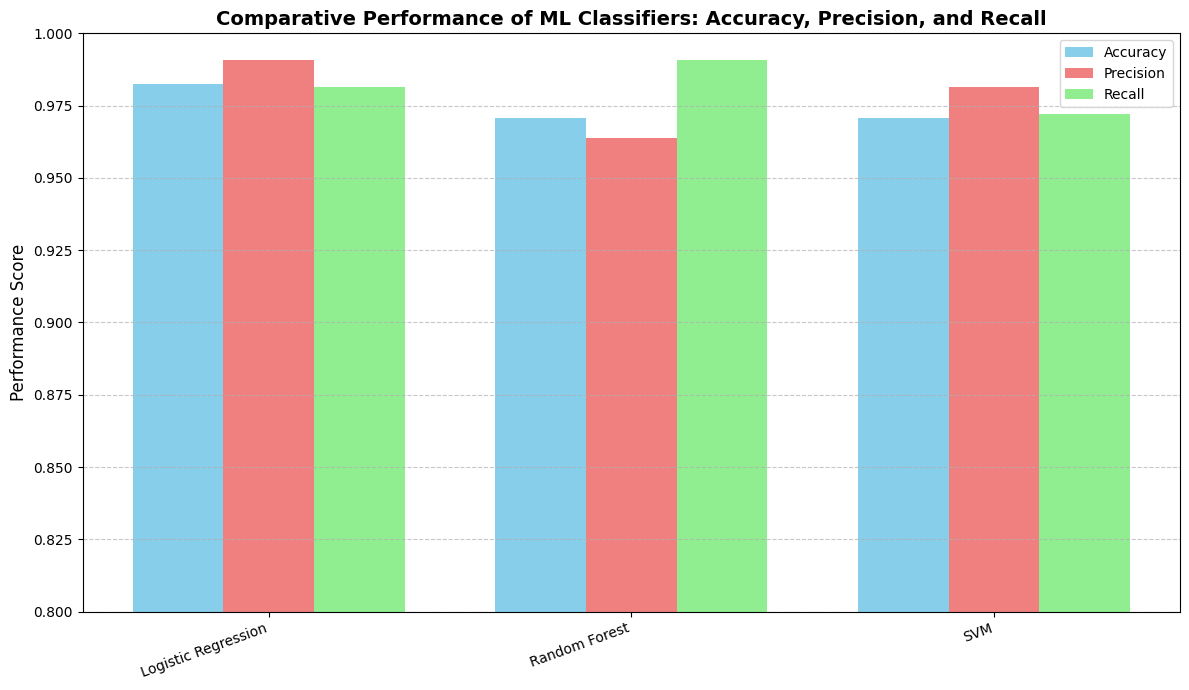

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Prepare the data for graphical representation
classifier_names = list(performance_metrics_all_models.keys())
all_accuracy_scores = [performance_metrics_all_models[model]['Accuracy'] for model in classifier_names]
all_precision_scores = [performance_metrics_all_models[model]['Precision'] for model in classifier_names]
all_recall_scores = [performance_metrics_all_models[model]['Recall'] for model in classifier_names]

# X-axis positions for the bars
x_positions = np.arange(len(classifier_names))
# The designated width for each individual bar
bar_width = 0.25

# Create the figure and axes for the plot
comparison_fig, chart_axis = plt.subplots(figsize=(12, 7))

# Plot the bars for each metric
accuracy_bars = chart_axis.bar(x_positions - bar_width, all_accuracy_scores, bar_width, label='Accuracy', color='skyblue')
precision_bars = chart_axis.bar(x_positions, all_precision_scores, bar_width, label='Precision', color='lightcoral')
recall_bars = chart_axis.bar(x_positions + bar_width, all_recall_scores, bar_width, label='Recall', color='lightgreen')

chart_axis.set_ylabel('Performance Score', fontsize=12)
chart_axis.set_title('Comparative Performance of ML Classifiers: Accuracy, Precision, and Recall', fontsize=14, fontweight='bold')
chart_axis.set_xticks(x_positions)
chart_axis.set_xticklabels(classifier_names, rotation=20, ha='right', fontsize=10)
chart_axis.legend(fontsize=10)
# Restrict y-axis for better metric visibility
chart_axis.set_ylim(0.8, 1.0)
chart_axis.grid(axis='y', linestyle='--', alpha=0.7)

comparison_fig.tight_layout()
plt.show()

#### Confusion Matrix:

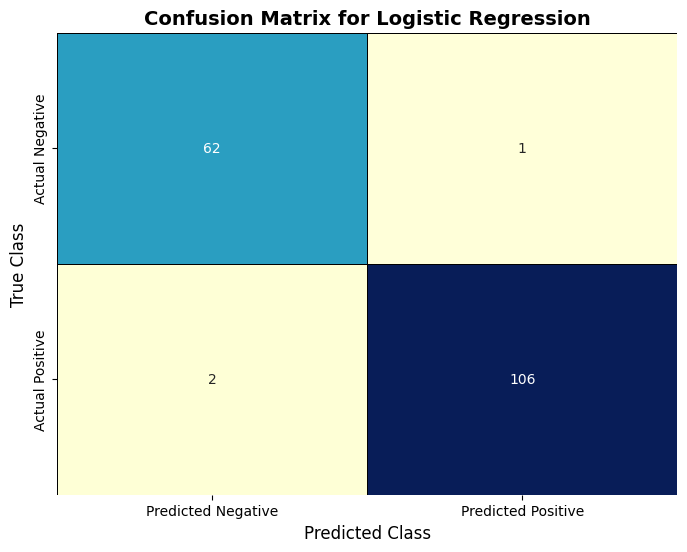

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Identify the model with the highest accuracy score
top_model_identifier = max(performance_metrics_all_models, key=lambda model: performance_metrics_all_models[model]['Accuracy'])

best_model_predictions = None
if top_model_identifier == 'Logistic Regression':
    best_model_predictions = predictions_logistic_reg
elif top_model_identifier == 'Random Forest':
    best_model_predictions = predictions_rf
elif top_model_identifier == 'SVM':
    best_model_predictions = predictions_svm

# Compute the confusion matrix for the identified best model
confusion_matrix_data = confusion_matrix(test_labels, best_model_predictions)

# confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_data, annot=True, fmt='d', cmap='YlGnBu', cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'],
            linewidths=.5, linecolor='black')
plt.title(f'Confusion Matrix for {top_model_identifier}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.show()

#### ROC Curve

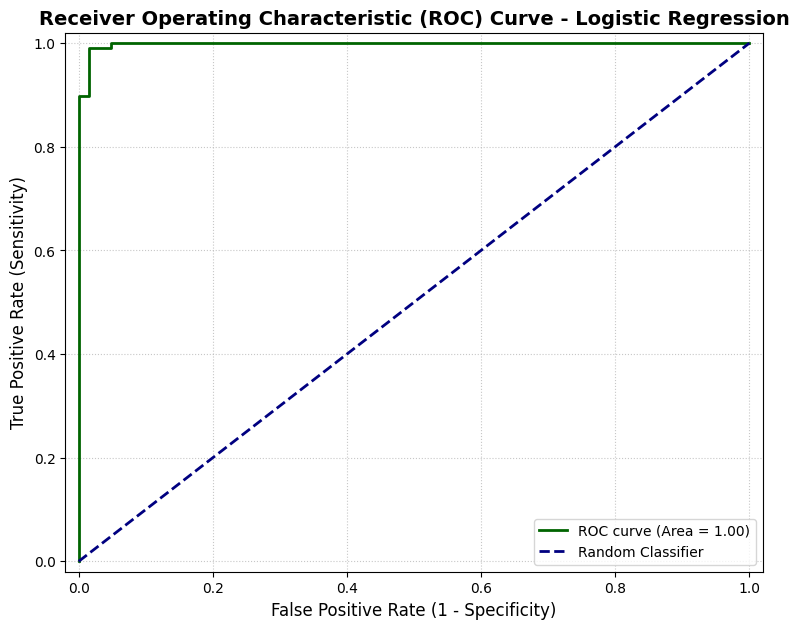

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Obtain the probability scores for the positive class from the Logistic Regression model
logistic_reg_probabilities = logistic_reg_classifier.predict_proba(test_features)[:, 1]

# Calculate the False Positive Rate (FPR), True Positive Rate (TPR), and thresholds for the ROC curve
false_positive_rates, true_positive_rates, probability_thresholds = roc_curve(test_labels, logistic_reg_probabilities)
roc_auc_score_lr = roc_auc_score(test_labels, logistic_reg_probabilities)

# Visualize the ROC curve
plt.figure(figsize=(9, 7))
plt.plot(false_positive_rates, true_positive_rates, color='darkgreen', lw=2,
         label=f'ROC curve (Area = {roc_auc_score_lr:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve - Logistic Regression', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()